In [ ]:
import numpy as np
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from sklearn.model_selection import train_test_split
import random

drive_path = '/content/drive/MyDrive/brain-tumor-mri-dataset'

all_images = []

for data_type in ['Training', 'Testing']:
    for tumor_type in ['notumor', 'pituitary', 'glioma', 'meningioma']:
        class_path = os.path.join(drive_path, data_type, tumor_type)
        class_images = [os.path.join(class_path, img) for img in os.listdir(class_path)]
        all_images.extend(class_images)

labels = [os.path.dirname(img).split(os.path.sep)[-1] for img in all_images]

train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, labels, test_size=0.2, random_state=42, stratify=labels
)

def extract_labels(image_paths):
    return [os.path.dirname(img).split(os.path.sep)[-1] for img in image_paths]

X_train = train_images
Y_train = extract_labels(X_train)
X_test = test_images
Y_test = extract_labels(X_test)

print("Selected Training Images:", len(X_train))
print("Training Labels:", len(Y_train))
print("Selected Testing Images:", len(X_test))
print("Testing Labels:", len(Y_test))

Selected Training Images: 5618
Training Labels: 5618
Selected Testing Images: 1405
Testing Labels: 1405


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
def preprocess_images(image_paths, target_size=(224, 224)):
    images = []
    for img_path in image_paths:
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        images.append(img_array)
    return np.array(images,dtype="float16")

In [ ]:
import tensorflow as tf

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_processed = preprocess_images(X_train)
X_test_processed = preprocess_images(X_test)

label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)
Y_test = label_encoder.transform(Y_test)

Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(4, activation='softmax'))

94765736/94765736 [==============================] - 5s 0us/step


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_processed, Y_train, epochs=20, validation_data=(X_test_processed, Y_test))

Epoch 1/20
176/176 [==============================] - 37s 165ms/step - loss: 0.7407 - accuracy: 0.7147 - val_loss: 0.3426 - val_accuracy: 0.8918
Epoch 2/20
176/176 [==============================] - 21s 121ms/step - loss: 0.3998 - accuracy: 0.8494 - val_loss: 0.2674 - val_accuracy: 0.9075
Epoch 3/20
176/176 [==============================] - 21s 121ms/step - loss: 0.3173 - accuracy: 0.8827 - val_loss: 0.2435 - val_accuracy: 0.9110
Epoch 4/20
176/176 [==============================] - 21s 121ms/step - loss: 0.2679 - accuracy: 0.9060 - val_loss: 0.2093 - val_accuracy: 0.9224
Epoch 5/20
176/176 [==============================] - 21s 122ms/step - loss: 0.2415 - accuracy: 0.9122 - val_loss: 0.1912 - val_accuracy: 0.9246
Epoch 6/20
176/176 [==============================] - 21s 121ms/step - loss: 0.2173 - accuracy: 0.9227 - val_loss: 0.1760 - val_accuracy: 0.9302
Epoch 7/20
176/176 [==============================] - 21s 121ms/step - loss: 0.1939 - accuracy: 0.9322 - val_loss: 0.1696 - val_ac

In [ ]:
test_loss, test_acc = model.evaluate(X_test_processed, Y_test)
print(f'Test accuracy: {test_acc}')

44/44 [==============================] - 4s 95ms/step - loss: 0.1130 - accuracy: 0.9544
Test accuracy: 0.954448401927948


In [ ]:
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [ ]:
predicted_labels = model.predict(X_test_processed).argmax(axis=1)

misclassified_indices = []

for i in range(len(Y_test)):
    if predicted_labels[i] != Y_test[i]:
        misclassified_indices.append(i)
print(misclassified_indices)

44/44 [==============================] - 5s 95ms/step
[53, 70, 74, 148, 157, 172, 194, 198, 204, 225, 251, 259, 298, 320, 335, 375, 424, 433, 463, 482, 483, 536, 537, 550, 566, 602, 617, 622, 624, 631, 666, 667, 694, 705, 718, 723, 728, 736, 755, 758, 760, 784, 802, 814, 872, 930, 945, 985, 1047, 1095, 1170, 1191, 1192, 1200, 1235, 1240, 1263, 1265, 1268, 1287, 1299, 1316, 1377, 1391]


In [ ]:
iteration_list=[]
accuracy_list=[]
misclassified_list=[]
iteration=0

iteration_list.append(iteration)
misclassified_list.append(len(misclassified_indices))
accuracy_list.append(test_acc)

In [ ]:
!pip install shap --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.5/533.5 kB 7.5 MB/s eta 0:00:00


In [ ]:
import shap

# # Define a masker using a blurred background
masker = shap.maskers.Image("inpaint_telea", (224,224,3))

In [ ]:
shap_val=0

def custom_loss_with_weights(Y_test, predicted_labels, sample_weights):
    original_loss = tf.keras.losses.sparse_categorical_crossentropy(Y_test, predicted_labels, from_logits=True)
    sample_weights = tf.cast(tf.reshape(sample_weights, (-1, 1)), tf.float32)
    weighted_loss = tf.reduce_mean(tf.multiply(sample_weights, original_loss))
    return weighted_loss

In [ ]:
accuracy_threshold = 0.99

while True:
    explainer = shap.Explainer(model, masker, output_names=["notumor", "pituitary", "glioma", "meningioma"])
    misclassified_images = X_test_processed[misclassified_indices]
    shap_values = explainer(misclassified_images, max_evals=500, batch_size=16)

    retrained_model = models.clone_model(model)
    retrained_model.set_weights(model.get_weights())

    if iteration > 0:
        retrained_model.set_weights(previous_retrained_model.get_weights())

    for channel_index in range(X_train_processed.shape[-1]):
        shap_values_channel = shap_values[..., channel_index].values
        base_shap_values_channel = shap_values[..., channel_index].base_values

        positive_shap_mask = base_shap_values_channel > 0
        positive_shap_positions = np.where(positive_shap_mask)

        shap_values_difference = shap_values_channel - base_shap_values_channel[:, np.newaxis, np.newaxis, np.newaxis]

        delta_weight = np.mean(shap_values_difference[positive_shap_positions])
        delta_weight=tf.cast(delta_weight, tf.float32)

        sample_weights = np.ones_like(Y_train)
        sample_weights[Y_train == channel_index] += delta_weight

    X_train_appended = np.concatenate((X_train_processed, X_test_processed[misclassified_indices]))
    Y_train_appended = np.concatenate((Y_train, Y_test[misclassified_indices]))

    retrained_model.compile(optimizer=Adam(learning_rate=0.0001),loss=lambda true_labels, predicted_labels: custom_loss_with_weights(true_labels, predicted_labels, sample_weights), metrics=['accuracy'])

    retrained_model.fit(X_train_appended, Y_train_appended, epochs=10, validation_data=(X_test_processed, Y_test))

    iteration += 1

    test_loss, test_accuracy = retrained_model.evaluate(X_test_processed, Y_test)

    predicted_labels = retrained_model.predict(X_test_processed).argmax(axis=1)

    misclassified_indices = [i for i in range(len(Y_test)) if predicted_labels[i] != Y_test[i]]

    iteration_list.append(iteration)
    accuracy_list.append(test_accuracy)
    misclassified_list.append(len(misclassified_indices))

    previous_retrained_model = retrained_model

    print(f"Iteration {iteration} - Test Accuracy: {test_accuracy}")

    with open(f'Iteration_{iteration}_model.pkl', 'wb') as file:
        pickle.dump(retrained_model, file)

    if test_accuracy >= accuracy_threshold:
        print(f"Accuracy reached the threshold ({accuracy_threshold}). Stopping training.")
        break

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   2%|▏         | 1/64 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▍         | 3/64 [00:43<10:06,  9.95s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

...

Epoch 1/10


"`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?


178/178 [==============================] - 29s 144ms/step - loss: 0.0638 - accuracy: 0.9688 - val_loss: 0.0682 - val_accuracy: 0.9623
Epoch 2/10
178/178 [==============================] - 22s 122ms/step - loss: 0.0649 - accuracy: 0.9680 - val_loss: 0.0670 - val_accuracy: 0.9623
Epoch 3/10
178/178 [==============================] - 21s 121ms/step - loss: 0.0584 - accuracy: 0.9720 - val_loss: 0.0537 - val_accuracy: 0.9730
Epoch 4/10
178/178 [==============================] - 22s 121ms/step - loss: 0.0511 - accuracy: 0.9775 - val_loss: 0.0591 - val_accuracy: 0.9644
Epoch 5/10
178/178 [==============================] - 22s 122ms/step - loss: 0.0496 - accuracy: 0.9778 - val_loss: 0.0438 - val_accuracy: 0.9815
Epoch 6/10
178/178 [==============================] - 22s 121ms/step - loss: 0.0424 - accuracy: 0.9815 - val_loss: 0.0473 - val_accuracy: 0.9744
Epoch 7/10
178/178 [==============================] - 22s 121ms/step - loss: 0.0422 - accuracy: 0.9833 - val_loss: 0.0407 - val_accuracy: 0.9

The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:     retrained_model.compile(optimizer=Adam(learning_rate=0.0001),loss=lambda true_labels, predicted_labels: custom_loss_with_weights(true_labels, predicted_labels, sample_weights), metrics=['accuracy'])



Accuracy reached the threshold (0.99). Stopping training.


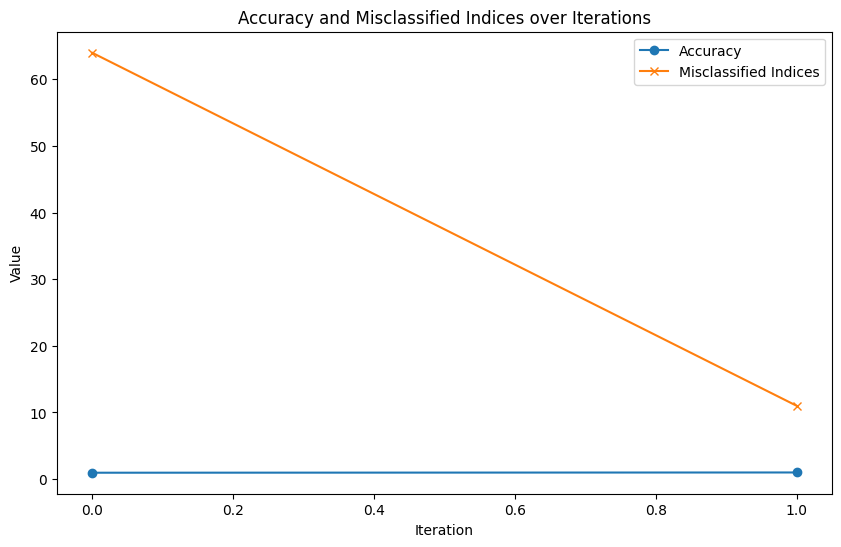

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(iteration_list, accuracy_list, label='Accuracy', marker='o')
plt.plot(iteration_list, misclassified_list, label='Misclassified Indices', marker='x')
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Accuracy and Misclassified Indices over Iterations')
plt.legend()
plt.show()

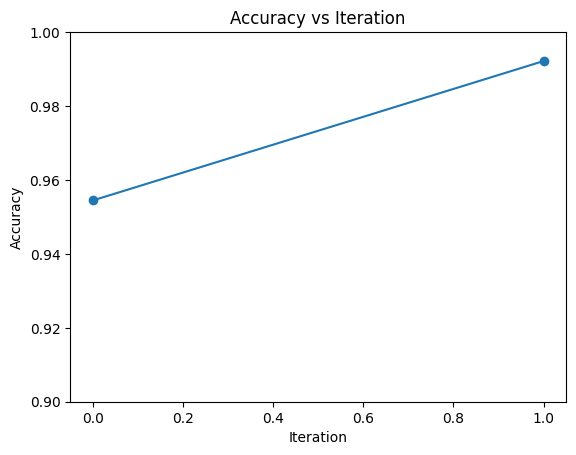

In [ ]:
plt.plot(iteration_list, accuracy_list, marker='o', linestyle='-')
plt.ylim(0.9, 1)

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Iteration')

plt.show()

In [ ]:
print(misclassified_list)

[64, 11]


44/44 [==============================] - 4s 96ms/step
Confusion Matrix:
[[323   1   0   0]
 [  6 323   0   0]
 [  0   1 399   0]
 [  1   2   0 349]]


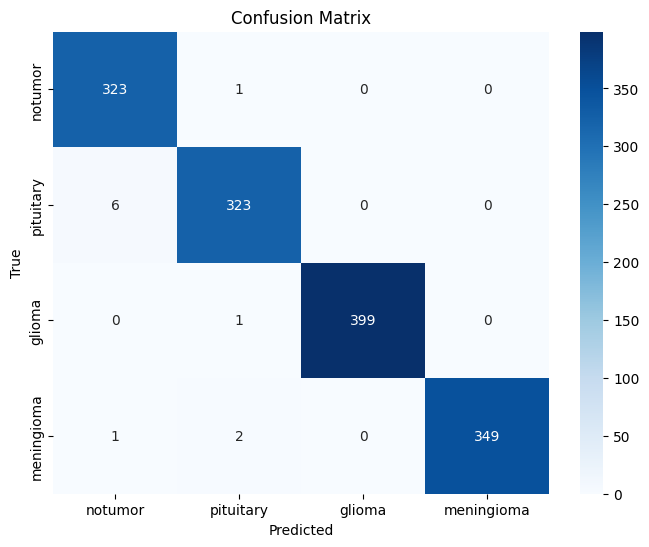

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
predicted_labels = retrained_model.predict(X_test_processed).argmax(axis=1)

conf_matrix = confusion_matrix(Y_test, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['notumor', 'pituitary', 'glioma', 'meningioma'], yticklabels=['notumor', 'pituitary', 'glioma', 'meningioma'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()